# **Import Libraries**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

# **Import DataSet**

In [2]:
df = pd.read_csv('/content/fashion_sales_messy_dataset.csv')

# **1. Data Understanding**

In [3]:
df.head()

,product_type,price,discount,rating,season,country,state,sales
0,Saree,2194.61,NaN,NaN,Winter,Australia,NSW,200
1,Dress,4613.92,NaN,1.3,NaN,Australia,NSW,60
2,Kurti,1701.72,20.0,2.5,Festive,UK,England,84
3,Top,277.20,20.0,3.5,NaN,UK,Scotland,2
4,Skirt,226.95,20.0,3.7,Winter,Canada,Quebec,58


#### **View Information**





In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_type  1500 non-null   object 
 1   price         1339 non-null   float64
 2   discount      927 non-null    float64
 3   rating        1257 non-null   float64
 4   season        1138 non-null   object 
 5   country       1500 non-null   object 
 6   state         1500 non-null   object 
 7   sales         1500 non-null   object 
dtypes: float64(3), object(5)
memory usage: 93.9+ KB


#### **View Rows & Columns**

In [5]:
df.shape

(1500, 8)

#### **View Column Names**


In [6]:
df.columns

Index(['product_type', 'price', 'discount', 'rating', 'season', 'country',
       'state', 'sales'],
      dtype='object')

#### **View Null Values**

In [7]:
df.isnull().sum()

,0
product_type,0
price,161
discount,573
rating,243
season,362
country,0
state,0
sales,0


# **2. Data Cleaning**

#### **1.Handling Missing Values**

In [8]:
# Filling price with Mean
df['price'] = df['price'].fillna(df['price'].mean())

# Filling Discount with 0
df['discount'] = df['discount'].fillna(0)

# Filling Rating with Mean
df['rating'] = df['rating'].fillna(df['rating'].mean())

# Filling Season with Mode
df['season'] = df['season'].fillna(df['season'].mode()[0])

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.head()

,product_type,price,discount,rating,season,country,state,sales
0,Saree,2194.61,0.0,2.961973,Winter,Australia,NSW,200
1,Dress,4613.92,0.0,1.300000,Winter,Australia,NSW,60
2,Kurti,1701.72,20.0,2.500000,Festive,UK,England,84
3,Top,277.20,20.0,3.500000,Winter,UK,Scotland,2
4,Skirt,226.95,20.0,3.700000,Winter,Canada,Quebec,58


In [11]:
df.isnull().sum()

,0
product_type,0
price,0
discount,0
rating,0
season,0
country,0
state,0
sales,0


#### **2.Fix Rows & Columns**

In [12]:
df.dtypes

,0
product_type,object
price,float64
discount,float64
rating,float64
season,object
country,object
state,object
sales,object


In [13]:
# Converting sales to Integer Type
df['sales'] = pd.to_numeric(df['sales'], errors='coerce').fillna(0).astype(int)

In [14]:
df.dtypes

,0
product_type,object
price,float64
discount,float64
rating,float64
season,object
country,object
state,object
sales,int64


In [15]:
df['product_type'].unique()

array(['Saree', 'Dress', 'Kurti', 'Top', 'Skirt', 'Jeans'], dtype=object)

#### **3.Finding Outliers**

In [16]:
 # select only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} → Outliers count:", len(outliers))

price → Outliers count: 0
discount → Outliers count: 0
rating → Outliers count: 0
sales → Outliers count: 0


In [17]:
fig = px.box(df, y=num_cols)
fig.update_layout(title="Box Plot for Outlier Detection")
fig.show()

# **3. Univariate Analysis**





In [18]:
df.describe().round(2)

,price,discount,rating,sales
count,1500.00,1500.00,1500.00,1500.00
mean,2606.03,12.59,2.96,96.01
std,1320.41,11.76,1.04,59.14
min,202.90,0.00,1.00,0.00
25%,1515.91,0.00,2.20,46.75
50%,2606.03,10.00,2.96,96.00
75%,3691.28,20.00,3.80,148.00
max,4999.87,30.00,5.00,200.00


In [19]:
# List of categorical variables
categorical_cols = ["product_type", "season", "country", "state"]

# Loop through each categorical variable and plot with Plotly
for col in categorical_cols:
    counts = df[col].value_counts()
    fig = px.bar(
        x=counts.index,
        y=counts.values,
        labels={"x": col, "y": "Frequency"},
        title=f"Frequency of {col}",
        text=counts.values,  # show counts on bars
        color=counts.values, # color intensity by frequency
        color_continuous_scale="Viridis"
    )
    fig.update_layout(xaxis_tickangle=45)  # rotate labels for readability
    fig.show()

# **4. Bivariate Analysis**

**1. Product vise Sales**

In [20]:
# using groupby Methode
top_products = df.groupby('product_type')['sales'].sum().sort_values(ascending=False)

print(top_products)

product_type
Top      25175
Saree    25010
Kurti    24128
Jeans    23529
Skirt    23371
Dress    22802
Name: sales, dtype: int64


In [21]:
# Group data
sales_data = df.groupby('product_type')['sales'].sum().reset_index()

# Bar chart
fig = px.bar(sales_data,
             x='product_type',
             y='sales',
             title="Product-wise Sales",
             text='sales')  # value display

fig.show()

##### **2. Product vise Average Discount**

In [22]:
# Group by product_type and calculate min, max, mean
discount_stats = df.groupby("product_type")["discount"].agg(["min", "max", "mean"]).reset_index()

print(discount_stats)

# Plot interactive bar chart for average discount
fig = px.bar(
    discount_stats,
    x="product_type",
    y="mean",
    title="Average Discount by Product Type",
    labels={"mean": "Average Discount (%)", "product_type": "Product Type"},
    text=discount_stats["mean"].round(1),
    color="mean",
    color_continuous_scale="Viridis"
)
fig.show()

  product_type  min   max       mean
0        Dress  0.0  30.0  13.142857
1        Jeans  0.0  30.0  13.611111
2        Kurti  0.0  30.0  11.829268
3        Saree  0.0  30.0  11.562500
4        Skirt  0.0  30.0  12.851406
5          Top  0.0  30.0  12.579365


 **3. Season vise Maximum Product Sales**

In [23]:
# Find product with maximum sales in each season
season_top_sales = df.groupby(["season", "product_type"])["sales"].sum().reset_index()
top_products = season_top_sales.loc[season_top_sales.groupby("season")["sales"].idxmax()]

print(season_top_sales)
print()
print(top_products)

# Plot interactive bar chart
fig = px.bar(
    top_products,
    x="season",
    y="sales",
    color="product_type",
    text="product_type",
    title="Top-Selling Product in Each Season",
    labels={"sales": "Total Sales", "season": "Season", "product_type": "Product Type"}
)
fig.show()

     season product_type  sales
0   Festive        Dress   5915
1   Festive        Jeans   3920
2   Festive        Kurti   5707
3   Festive        Saree   6301
4   Festive        Skirt   6092
5   Festive          Top   6392
6    Summer        Dress   5362
7    Summer        Jeans   5143
8    Summer        Kurti   6974
9    Summer        Saree   7435
10   Summer        Skirt   5935
11   Summer          Top   5009
12   Winter        Dress  11525
13   Winter        Jeans  14466
14   Winter        Kurti  11447
15   Winter        Saree  11274
16   Winter        Skirt  11344
17   Winter          Top  13774

     season product_type  sales
5   Festive          Top   6392
9    Summer        Saree   7435
13   Winter        Jeans  14466


# **5. Multivariate Analysis**

###### **1. Country vs Product Type vs Sales**

In [24]:
#Country vs Product Type vs Sales
country_sales = df.groupby(["country","product_type"])["sales"].sum().reset_index()
fig = px.bar(country_sales, x="country", y="sales", color="product_type",
             title="Total Sales by Product Type per Country", barmode="group")
fig.show()

##### **2. Festival Season VS Total Product Sales**

In [25]:
# Filter only Festive season
festive_df = df[df["season"] == "Festive"]

# Group by product_type and sum sales
festive_sales = festive_df.groupby("product_type")["sales"].sum().reset_index()

# Find product with highest sales
top_product = festive_sales.loc[festive_sales["sales"].idxmax()]
print("Top product in Festive season:", top_product["product_type"], "with sales:", top_product["sales"])

# Plot interactive bar chart
fig = px.bar(
    festive_sales,
    x="product_type",
    y="sales",
    color="product_type",
    text="sales",
    title="Total Sales by Product Type (Festive Season)",
    labels={"sales": "Total Sales", "product_type": "Product Type"}
)
fig.show()

Top product in Festive season: Top with sales: 6392


# **6. Correlation Finding**

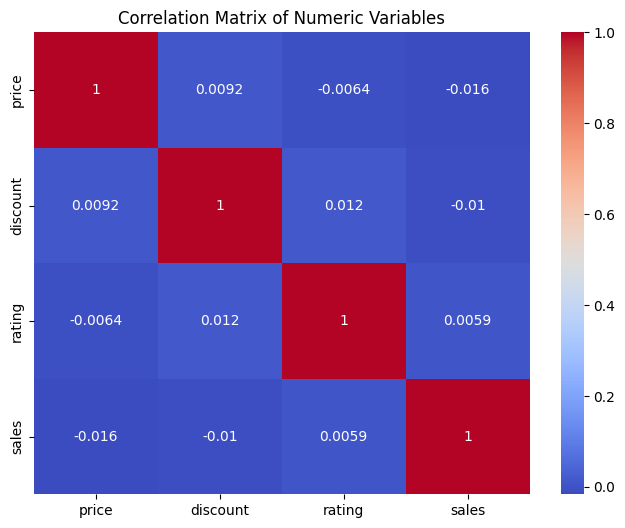

In [26]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

# **7. Trend Analysis -> V Shape**

In [27]:
# Aggregate sales by season
season_sales = df.groupby("season")["sales"].sum().reset_index()

# Sort seasons in logical order
season_order = ["Winter", "Festive", "Summer"]
season_sales["season"] = pd.Categorical(season_sales["season"], categories=season_order, ordered=True)
season_sales = season_sales.sort_values("season")

# Plot interactive line chart
fig = px.line(
    season_sales,
    x="season",
    y="sales",
    markers=True,
    title="Seasonal Sales Trend (V-shape pattern)",
    labels={"sales": "Total Sales", "season": "Season"}
)
fig.show()


# **8. Hypothesis Testing**

Let’s test:

Statement : “Discounts significantly increase sales.”

Null Hypothesis (H₀):
 Discounts have no effect on sales.

Alternative Hypothesis (H₁) : Discounts increase sales.


### **Types:**



1.   Z-Test --> Large Sample (n>30)
2.   T-Test --> Small Sample (n<30)
3.   Chi-Square -->  Categorical data
4.   ANOVA  --> Compare More than 2 groups



In [28]:
# Create two groups: with discount vs without discount
sales_with_discount = df[df["discount"] > 0]["sales"]
sales_without_discount = df[df["discount"] == 0]["sales"]

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(sales_with_discount, sales_without_discount, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Discounts significantly increase sales.")
else:
    print("Fail to reject H₀: No significant effect of discounts on sales.")


T-statistic: -0.1363393890246567
P-value: 0.891575876347967
Fail to reject H₀: No significant effect of discounts on sales.


In [35]:
df["discount_flag"] = df["discount"].apply(lambda x: "With Discount" if x > 0 else "No Discount")
df = df.dropna(subset=["sales", "discount_flag"])

fig = px.box(
    df,
    x="discount_flag",
    y="sales",
    color="discount_flag",
    title="Sales Comparison: With vs Without Discount",
    points="outliers"  # show outliers
)

fig.show()

# **9. Probability**

**Measuring the chance that an event will occur**

In [36]:
# --- 1. Probability: Rating > 4 ---
prob_rating_high = (df["rating"] > 4).mean()
print("Probability that rating > 4:", prob_rating_high)

# --- 2. Probability: Discount > 20% ---
prob_discount_high = (df["discount"] > 20).mean()
print("Probability that discount > 20%:", prob_discount_high)

# --- 3. Probability: Sales > 500 ---
prob_sales_high = (df["sales"] > 500).mean()
print("Probability that sales > 500:", prob_sales_high)

Probability that rating > 4: 0.186
Probability that discount > 20%: 0.21266666666666667
Probability that sales > 500: 0.0


# **10. Sampling Techiques**

Selecting the rigth subset from a Population.

**Types of Sampling Techniques**

1.   Simple Random Sampling
2.   Systematic Sampling
3.   Stratified Sampling
4.   Cluster Sampling



**10.1. Simple Random Sampling**

Every individuals has equal chance of selection

In [37]:
# --- 1. Simple Random Sampling (10 rows) ---
simple_random = df.sample(n=10, random_state=42)
print("Simple Random Sample:\n", simple_random)

Simple Random Sample:
      product_type        price  discount  rating   season    country  \
1116        Kurti  4693.630000       0.0     1.6   Winter     Canada   
1368        Jeans   608.240000       0.0     4.3  Festive         UK   
422         Saree  2606.028275      10.0     4.7   Summer         UK   
413         Saree  4277.700000      20.0     2.2  Festive     Canada   
451         Skirt  1241.510000      20.0     2.7   Winter         UK   
861         Kurti   898.910000      30.0     1.6   Summer        USA   
1063        Saree   292.260000      10.0     3.1   Winter  Australia   
741         Kurti  4414.220000      30.0     3.3  Festive        USA   
1272          Top  3199.540000      10.0     2.8   Summer     Canada   
259         Dress  1590.680000       0.0     4.2   Summer        USA   

           state  sales  discount_flag  
1116     Ontario     72    No Discount  
1368     England     95    No Discount  
422      England     53  With Discount  
413      Ontario    

**10.2. Systematic Sampling**

Every Kth individuals is selected from a list

In [38]:
# --- 2. Systematic Sampling (every 10th row) ---
systematic = df.iloc[::10]
print("Systematic Sample:\n", systematic)

Systematic Sample:
      product_type        price  discount    rating   season    country  \
0           Saree  2194.610000       0.0  2.961973   Winter  Australia   
10          Skirt  3747.550000       0.0  2.800000  Festive         UK   
20          Kurti  4517.140000       0.0  2.700000   Winter         UK   
30          Kurti  4547.340000      10.0  1.500000   Summer      India   
40          Saree  2629.290000      10.0  2.100000   Winter     Canada   
...           ...          ...       ...       ...      ...        ...   
1450        Saree   734.540000      30.0  3.800000  Festive  Australia   
1460        Kurti  3696.480000       0.0  4.400000   Summer     Canada   
1470        Saree  2606.028275      10.0  4.800000   Winter  Australia   
1480        Skirt  1875.440000       0.0  1.400000   Winter        USA   
1490        Skirt  2606.028275      10.0  2.961973  Festive  Australia   

            state  sales  discount_flag  
0             NSW    200    No Discount  
10     

 **10.3. Stratified Sampling**

 The population is divided into distinct subgroups

In [39]:
# --- 3. Stratified Sampling (by season, 5 samples each) ---
stratified = df.groupby("season", group_keys=False).apply(lambda x: x.sample(min(len(x),5), random_state=42))
print("Stratified Sample:\n", stratified.head())


Stratified Sample:
      product_type    price  discount    rating   season country     state  \
461         Saree  3993.60      20.0  1.400000  Festive     USA     Texas   
698         Saree  4043.09       0.0  4.000000  Festive      UK  Scotland   
1193        Dress  4532.46      20.0  2.961973  Festive   India    Kerala   
898         Jeans   447.87       0.0  4.200000  Festive   India    Kerala   
1388        Skirt   515.06       0.0  3.000000  Festive  Canada   Ontario   

      sales  discount_flag  
461     139  With Discount  
698     145    No Discount  
1193     83  With Discount  
898     200    No Discount  
1388    194    No Discount  


/tmp/ipykernel_678/1577296390.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



**10.4. Cluster Sampling**

The population is divided into clusters (often based on geography or groups), and entire clusters are randomly selected for analysis instead of individual elements.

In [40]:
df['country'].unique()

array(['Australia', 'UK', 'Canada', 'India', 'USA'], dtype=object)

In [41]:
# --- 4. Cluster Sampling (pick 2 random countries, then all rows from them) ---
countries = df["country"].unique()
print("Countries : ",countries)
chosen_clusters = np.random.choice(countries, size=2, replace=False)
cluster_sample = df[df["country"].isin(chosen_clusters)]
print("Cluster Sample (Countries chosen):", chosen_clusters)
print(cluster_sample.head())

Countries :  ['Australia' 'UK' 'Canada' 'India' 'USA']
Cluster Sample (Countries chosen): ['USA' 'Australia']
   product_type    price  discount    rating  season    country       state  \
0         Saree  2194.61       0.0  2.961973  Winter  Australia         NSW   
1         Dress  4613.92       0.0  1.300000  Winter  Australia         NSW   
6           Top  4737.35      10.0  4.200000  Winter        USA        Ohio   
11        Kurti   217.77      20.0  1.700000  Winter  Australia  Queensland   
12        Skirt  1818.32      30.0  3.900000  Summer  Australia  Queensland   

    sales  discount_flag  
0     200    No Discount  
1      60    No Discount  
6      80  With Discount  
11      0  With Discount  
12     48  With Discount  


# **11. Automation**

Automating pipeline means running all analysis steps automatically using functions.Instead of doing step-by-step manually.
we do --> one function → everything runs

**Pipeline Function**

In [42]:
def eda_pipeline(file_path):

    # 1. Load dataset
    df = pd.read_csv(file_path)
    print("\n✅ Dataset Loaded")
    print("\nShape:", df.shape)


    # 2. Handle missing values
    # Fill numeric NaN with median, categorical NaN with mode
    for col in df.columns:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("\n✅ Missing values handled")


    # 3. Remove duplicates
    df = df.drop_duplicates()
    print("\n✅ Duplicates removed")


    # 4. Summary statistics
    print("\n📊 Summary Statistics:\n", df.describe(include="all"))



**Run Pipeline**

In [43]:
clean_df = eda_pipeline("fashion_sales_messy_dataset.csv")


✅ Dataset Loaded

Shape: (1500, 8)

✅ Missing values handled

✅ Duplicates removed

📊 Summary Statistics:
        product_type        price     discount       rating  season country  \
count          1500  1500.000000  1500.000000  1500.000000    1500    1500   
unique            6          NaN          NaN          NaN       3       5   
top           Saree          NaN          NaN          NaN  Winter  Canada   
freq            256          NaN          NaN          NaN     776     315   
mean            NaN  2609.067067    20.233333     2.951933     NaN     NaN   
std             NaN  1320.442647     6.338165     1.041547     NaN     NaN   
min             NaN   202.900000    10.000000     1.000000     NaN     NaN   
25%             NaN  1515.907500    20.000000     2.200000     NaN     NaN   
50%             NaN  2634.340000    20.000000     2.900000     NaN     NaN   
75%             NaN  3691.277500    20.000000     3.800000     NaN     NaN   
max             NaN  4999.870000  

In [44]:
pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 57.9 MB/s eta 0:00:00


In [45]:
import pandas as pd
import sweetviz as sv

df = pd.read_csv("/content/fashion_sales_messy_dataset.csv")

report = sv.analyze(df)

report.show_html("Fashion_data_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report Fashion_data_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## **Insights:**


1.   Sales are low during the Festive season and high in Summer, forming a V shape.
2.   Winter sales are average and fairly stable.
3.   Overall sales change based on the season.



## **Recommendations:**


1.   Give offers or discounts during the Festive season to increase sales.
2.   Focus more on Summer for marketing and stock since sales are highest.
